# Evaluacion de modelos

Metricas, explicabilidad (SHAP) y seleccion del mejor modelo.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import pandas as pd
import joblib
project_root = str(Path.cwd().parent)

if project_root not in sys.path:
    sys.path.append(project_root)

from scripts.evaluation.metrics import evaluate_classification
from scripts.explainability.explain_score import explain_model

c:\Users\H P\Desktop\hackAIthon\fraudIA-Novo-2S1R\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ROOT = Path("..").resolve()
DATA_PROCESSED = ROOT / "data" / "processed"
ARTIFACT = ROOT / "artifact"
FINAL_DIR = ARTIFACT / "final-model"
FINAL_DIR.mkdir(parents=True, exist_ok=True)

preds_path = DATA_PROCESSED / "predictions.csv"
preds = pd.read_csv(preds_path)
preds.head()

,model,y_true,y_pred,y_prob
0,logistic_regression,0,0,1.468401e-55
1,logistic_regression,0,0,0.000000e+00
2,logistic_regression,0,0,8.539582e-282
3,logistic_regression,1,1,1.000000e+00
4,logistic_regression,0,0,8.649274e-230


In [11]:
import importlib
import scripts.text.similarity as similarity_module
similarity_module = importlib.reload(similarity_module)
build_narrativas_similares = similarity_module.main

narrativas_path = build_narrativas_similares(
    input_path=DATA_PROCESSED / "features_siniestros.csv",
    output_path=DATA_PROCESSED / "narrativas_similares.csv",
)

narrativas_similares = pd.read_csv(narrativas_path)
narrativas_similares.head()

,id_siniestro,id_similar,similaridad
0,3,33,0.852134
1,3,60,0.840206
2,3,70,0.815810
3,3,54,0.815810
4,4,74,0.819391


In [3]:
models = {
    "logistic_regression": ARTIFACT / "logistic_regression.pkl",
    "decision_tree": ARTIFACT / "decision_tree.pkl",
    "random_forest": ARTIFACT / "random_forest.pkl",
}
models

{'logistic_regression': WindowsPath('C:/Users/H P/Desktop/hackAIthon/fraudIA-Novo-2S1R/artifact/logistic_regression.pkl'),
 'decision_tree': WindowsPath('C:/Users/H P/Desktop/hackAIthon/fraudIA-Novo-2S1R/artifact/decision_tree.pkl'),
 'random_forest': WindowsPath('C:/Users/H P/Desktop/hackAIthon/fraudIA-Novo-2S1R/artifact/random_forest.pkl')}


--- Evaluando modelo: logistic_regression ---


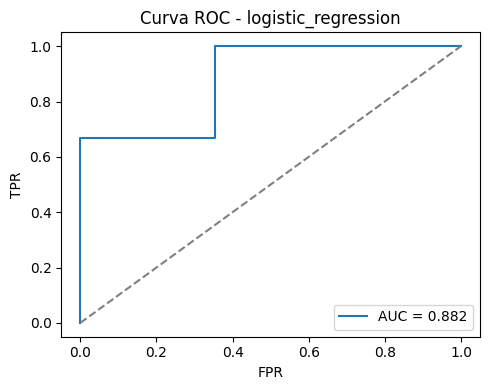

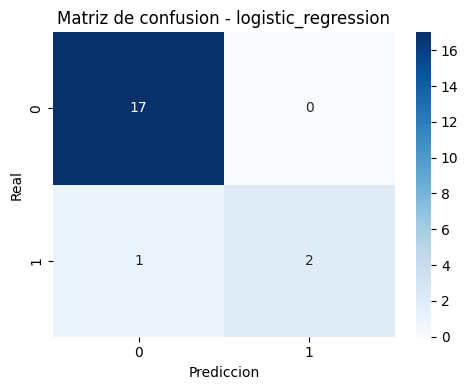


--- Evaluando modelo: decision_tree ---


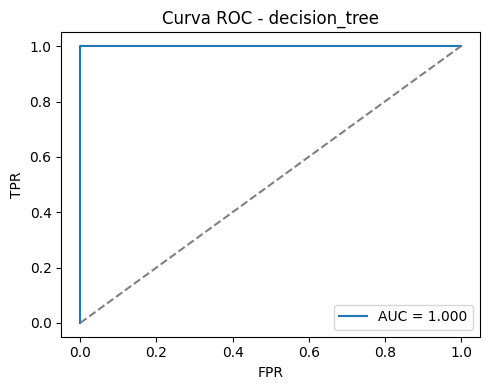

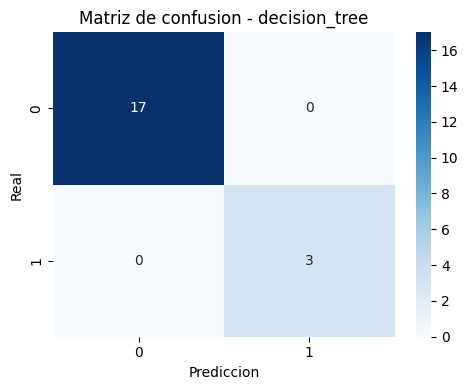


--- Evaluando modelo: random_forest ---


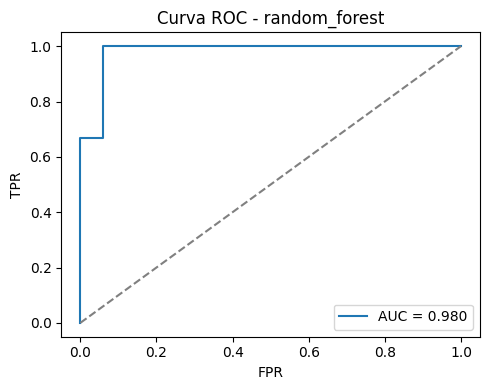

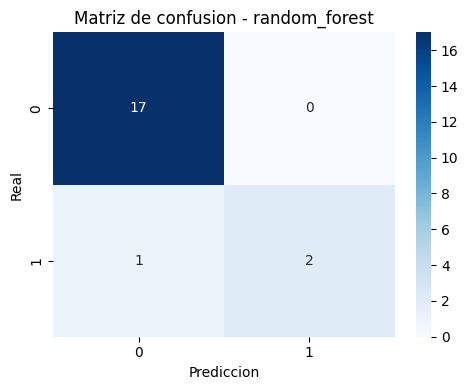

,accuracy,precision,recall,f1_score,auc_roc,model
1,1.00,1.0,1.000000,1.0,1.000000,decision_tree
0,0.95,1.0,0.666667,0.8,0.882353,logistic_regression
2,0.95,1.0,0.666667,0.8,0.980392,random_forest


In [4]:
metrics_rows = []

if "model" in preds.columns:
    for model_name in preds["model"].unique():
        print(f"\n--- Evaluando modelo: {model_name} ---")
        subset = preds[preds["model"] == model_name]
        
        metrics = evaluate_classification(
            subset["y_true"].to_numpy(),
            subset["y_pred"].to_numpy(),
            subset["y_prob"].to_numpy(),
            model_name=model_name
        )
        metrics["model"] = model_name
        metrics_rows.append(metrics)
else:
    metrics = evaluate_classification(
        preds["y_true"].to_numpy(),
        preds["y_pred"].to_numpy(),
        preds["y_prob"].to_numpy()
    )
    metrics_rows.append(metrics)

metrics_df = pd.DataFrame(metrics_rows)

display(metrics_df.sort_values("f1_score", ascending=False))

In [5]:
best_model_name = metrics_df.sort_values("f1_score", ascending=False).iloc[0]["model"]
best_model_name

'decision_tree'

In [6]:
best_model_path = models[best_model_name]
best_model = joblib.load(best_model_path)
best_model

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


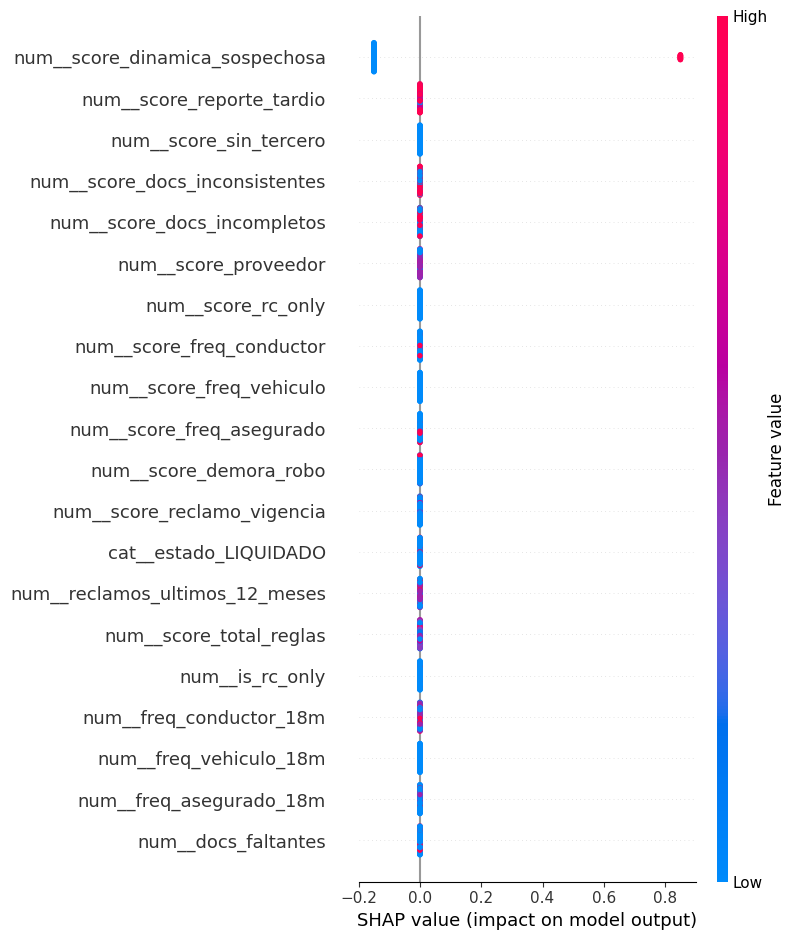

In [7]:
features = pd.read_csv(DATA_PROCESSED / "features_siniestros.csv")
target_col = "etiqueta_fraude_simulada"
drop_cols = [
    "id_siniestro",
    "id_poliza",
    "id_asegurado",
    "id_proveedor",
    "descripcion",
    "created_at",
    "updated_at",
]

X = features.drop(columns=[c for c in drop_cols if c in features.columns] + [target_col])

explain_model(best_model, X)

In [8]:
joblib.dump(best_model, FINAL_DIR / "model.pkl")
(FINAL_DIR / "model.pkl").exists()

True